# Feature Selection Methods

1- Lasso 

2- Elastic Net

3- MRMR

4- Kaggle Challenge


In [1]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv') #make sure to replace with your data directory
df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

In [2]:
X

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1


In [3]:
y.value_counts(normalize=True)

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

# Create train and test sets

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=42)

In [5]:
print('X train shape: ',X_train.shape)
print('y train shape: ',y_train.shape)
print('X test shape: ',X_test.shape)
print('y test shape: ',y_test.shape)
print('y train: ',y_train.value_counts(normalize=True))
print('y test: ',y_test.value_counts(normalize=True))

X train shape:  (209, 11)
y train shape:  (209,)
X test shape:  (90, 11)
y test shape:  (90,)
y train:  DEATH_EVENT
0    0.679426
1    0.320574
Name: proportion, dtype: float64
y test:  DEATH_EVENT
0    0.677778
1    0.322222
Name: proportion, dtype: float64


In [6]:
feature_names = X.columns
feature_names

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='object')

# Normalize Data

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Feature selection on train set

# Lasso Feature selection 

In [12]:
from sklearn import linear_model
model = linear_model.LassoCV(cv=5)
lasso_regression = model.fit(X_train,y_train)
B2 = lasso_regression.coef_
B2


array([ 0.0409842 ,  0.0155569 ,  0.0435928 ,  0.01277368, -0.10970532,
        0.01432047, -0.        ,  0.12604567, -0.01690006,  0.        ,
        0.        ])

In [13]:
selected_features = feature_names[B2 != 0]
selected_features
#selected_features = X.columns[abs(B2) >= 0.03]

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium'],
      dtype='object')

In [16]:
selected_features = feature_names[abs(B2) >= 0.02]
selected_features

Index(['age', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine'],
      dtype='object')

# Elastic Net

In [19]:
from sklearn.linear_model import ElasticNetCV
enet_cv = ElasticNetCV(
    l1_ratio=0.5,         # 0 = ridge, 1 = lasso
    n_alphas=100,
    cv=5,                 # number of CV folds
    max_iter=1000,
    tol=1e-7,
    n_jobs=-1             # use all cores
)

# Fit model
enet_cv.fit(X_train, y_train)
selected_features = feature_names[enet_cv.coef_ != 0]
selected_features

/opt/anaconda3/envs/vmb_env_py311/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium', 'smoking'],
      dtype='object')

In [23]:
selected_features = feature_names[abs(enet_cv.coef_) >= 0.02]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine', 'serum_sodium'],
      dtype='object')

# MRMR : Minimum Redundancy Maximum Relevance

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# RESET INDEX
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

from mrmr import mrmr_classif

selected_features = mrmr_classif(X=X_train_scaled, y=y_train, K=2)
selected_features

100%|██████████| 2/2 [00:00<00:00, 21.78it/s]


['serum_creatinine', 'ejection_fraction']

# Random Forest Feature Ranking 

                     Feature  Importance
7           serum_creatinine    0.226576
4          ejection_fraction    0.189003
2   creatinine_phosphokinase    0.137817
6                  platelets    0.125251
0                        age    0.113467
8               serum_sodium    0.100224
5        high_blood_pressure    0.023073
1                    anaemia    0.021576
3                   diabetes    0.021542
10                   smoking    0.021240
9                        sex    0.020232


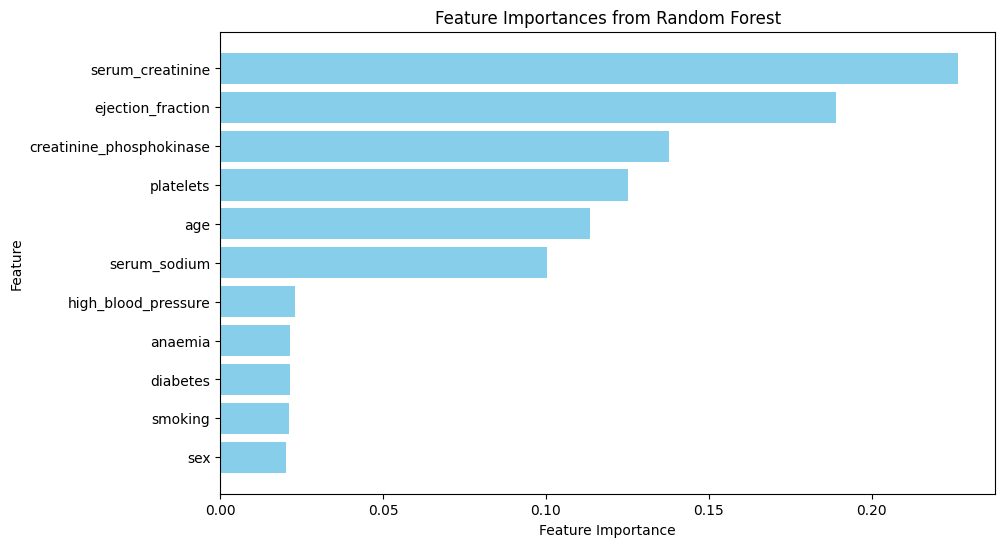

In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Extract feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print(feature_importances_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

# Train on top 2 features: 

In [54]:
# train on top 2 features: 
selected_features = feature_names[abs(B2) >= 0.05]
print(f'features used are: {selected_features}')

X_train_top_features = X_train.loc[:,selected_features]
X_test_top_features = X_test.loc[:,selected_features]

# Random Forest model 
# Train a Random Forest model
model = RandomForestClassifier()
model.fit(X_train_top_features, y_train)
preds = model.predict(X_test_top_features)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))


features used are: Index(['ejection_fraction', 'serum_creatinine'], dtype='object')
Accuracy: 0.7888888888888889
Precision: 0.6923076923076923
Recall: 0.6206896551724138
F1-Score: 0.6545454545454545


In [56]:
#model with no feature selection 

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

Accuracy: 0.7222222222222222
Precision: 0.5833333333333334
Recall: 0.4827586206896552
F1-Score: 0.5283018867924528


# Kaggle Competition 

## Kaggle Challenge Instructions

Use everything you have learned in the previous weeks to develop a new algorithm that achieves the highest possible test accuracy.

Perform the train–test split exactly as specified below. Do not modify the provided cell.

Use the training set only for:

Feature selection

Hyperparameter optimization

Cross-validation

The test set must be used only for final evaluation of your algorithm, and you must report the test accuracy.

Performing any steps on the test set other than final evaluation will be considered cheating and will result in disqualification from the challenge.


In [61]:
#Don't modify this cell
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# RESET INDEX
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)